# Global regulation of a latent factor

In [ ]:
# Dataset locations for this notebook come from ../datasets.yaml.
# Edit that file to point at your own copies -- do not hardcode paths below.
from focal.io import DatasetPaths

# DatasetPaths.find() walks up from the kernel's working directory to the first
# datasets.yaml (or uses $FOCAL_DATASETS), so it works wherever Jupyter was started.
config = DatasetPaths.find()


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import dictys
import joblib

In [2]:
import pickle

import matplotlib                    # for matplotlib.animation.writers
from dictys.net import stat          # both were leaked by the old star imports

from focal.temporal import *      # classes AND their figures (was episode_plots)
from focal.utils import *         # gene / state helpers (was utils_custom)

In [4]:
# Define file paths 
output_folder = os.path.join(config.BCELL_BASE, 'output')

In [ ]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file(config.DYNAMIC_H5)

#### Getting attributes of the dynamic object

In [6]:
psuedotime_values_of_windows = dictys_dynamic_object.point['s'].dist
#save the psuedotime values of the windows as csv file
psuedotime_values_of_windows_df = pd.DataFrame(psuedotime_values_of_windows[:,0], columns=['psuedotime'])
psuedotime_values_of_windows_df.to_csv(os.path.join(output_folder, 'psuedotime_values_of_windows.csv'), index=False)

In [ ]:
# load cell labels
PATH_TO_CELL_LABELS = config.DAY_LABELS
day_labels_df = pd.read_csv(PATH_TO_CELL_LABELS)
day_labels = day_labels_df["cell_type_major"].tolist()
# get cell labels per window
day_labels_per_window = get_state_labels_in_window(dictys_dynamic_object, day_labels)

In [ ]:
cell_count_per_window_df = window_labels_to_count_df(day_labels_per_window)
display(cell_count_per_window_df.head())
#save the cell_count_per_window_df as a csv
cell_count_per_window_df.to_csv(os.path.join(output_folder, 'day_count_per_window_df.csv'), index=True)

# Visualize custom TFs

PlasmaBlast
  Saved: /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/figures_suppli/PlasmaBlast_fig0.pdf
  Saved: /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/figures_suppli/PlasmaBlast_fig1.pdf
  Saved: /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/figures_suppli/PlasmaBlast_fig2.pdf
  Saved: /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/figures_suppli/PlasmaBlast_fig3.pdf


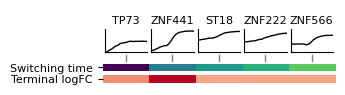

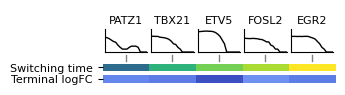

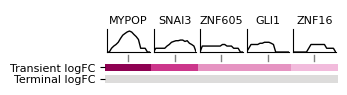

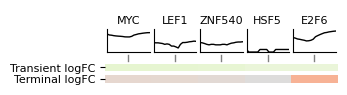

GerminalCenter
  Saved: /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/figures_suppli/GerminalCenter_fig0.pdf
  Saved: /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/figures_suppli/GerminalCenter_fig1.pdf
  Saved: /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/figures_suppli/GerminalCenter_fig2.pdf
  Saved: /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/figures_suppli/GerminalCenter_fig3.pdf


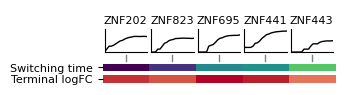

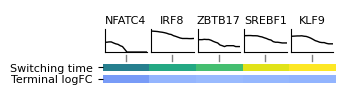

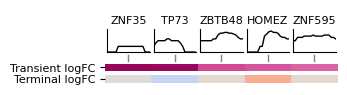

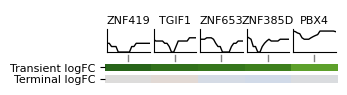

In [11]:
import os

output_dir = config.FIGURES_SUPPL
os.makedirs(output_dir, exist_ok=True)

branches = {
    'PlasmaBlast': (0, 2),
    'GerminalCenter': (0, 3)
}

for branchname in branches:
    print(branchname)
    figs = dictys_dynamic_object.draw_discover(
        *branches[branchname],
        ntops=(5, 5, 5, 5),
        num=20,
        dist=0.001,
        mode='regulation'
    )
    for i, fig in enumerate(figs):
        filepath = os.path.join(output_dir, f"{branchname}_fig{i}.pdf")
        fig[0].savefig(filepath, bbox_inches='tight')
        print(f"  Saved: {filepath}")
    plt.show()

## Get TF activity in LF geneset
### Subsetting the graph to only a few TFs and genes of interest

In [6]:
custom_tfs = ['IRF8','NFATC2', 'BCL6']
tf_indices_custom, tf_gene_indices_custom, missing_tfs = get_tf_indices(dictys_dynamic_object, custom_tfs)
display(tf_indices_custom)
display(missing_tfs) #not present in the motif databases, hence not in the final GRN. QC filtering has been masked for important genes to not dropout.

[121, 178, 22]

[]

In [7]:
latent_factor_folder = config.LF_FOLDER
lf_blimp1_file = f"{latent_factor_folder}/feature_list_Z5_PRDM1_KO.txt"
lf_irf4_file = f"{latent_factor_folder}/feature_list_Z4_IRF4_KO.txt"
lf_blimp1 = pd.read_csv(lf_blimp1_file, sep='\t')['names'].tolist()
lf_irf4 = pd.read_csv(lf_irf4_file, sep='\t')['names'].tolist()

In [68]:
lf_geneset = lf_blimp1

In [69]:
pseudotime_object = SmoothedCurvesGRN(dictys_dynamic_object,
    trajectory_range=(1,3), # day-1 start to gc end
    num_points=40,
    dist=0.001,
    sparsity=0.01,
    mode="expression")

In [70]:
# get lcpm chars for these genes
lcpm_dcurve, dtime = pseudotime_object.get_smoothed_curves(mode='expression')
# remove genes with names starting with ZNF and ZBTB
lcpm_dcurve = lcpm_dcurve[~lcpm_dcurve.index.str.startswith('ZNF') & ~lcpm_dcurve.index.str.startswith('ZBTB')]
# slice the dcurve for the lf genes using gene names which are indices in pandas df
lf_lcpm_dcurve = lcpm_dcurve.loc[lf_geneset]
display(lf_lcpm_dcurve.shape)

(40, 40)

In [71]:
pts, fsmooth = dictys_dynamic_object.linspace(1,3,40,0.001) # day-1 start to gc end
stat1_net = fsmooth(stat.net(dictys_dynamic_object, varname='w_in')) #varname=w_in loads total effect network
stat1_netbin = stat.fbinarize(stat1_net,sparsity=0.01)
stat1_x=stat.pseudotime(dictys_dynamic_object,pts)
dtime = pd.Series(stat1_x.compute(pts)[0])

In [73]:
# compute the binary network to get the indices of genes to keep based on sparsity
dnetbin = stat1_netbin.compute(pts)
display(dnetbin.shape)

(551, 11907, 40)

In [74]:
# compute the weighted network
dnet = stat1_net.compute(pts)
display(dnet.shape)

(551, 11907, 40)

In [75]:
lf_genes_indices = get_gene_indices(dictys_dynamic_object, lf_geneset)
display(len(lf_genes_indices))  

40

In [76]:
subnetworks_bin = dnetbin[np.ix_(range(dnetbin.shape[0]), lf_genes_indices, range(dnetbin.shape[2]))]
display(subnetworks_bin.shape)

(551, 40, 40)

In [77]:
# Get the subnetworks for the kept TFs
filtered_subnetworks = dnet[np.ix_(tf_indices_custom, lf_genes_indices, range(dnet.shape[2]))]
display(filtered_subnetworks.shape)

(3, 40, 40)

In [78]:
# Create multi-index tuples (all combinations of TF-target pairs)
index_tuples = [(tf, target) for tf in custom_tfs for target in lf_geneset]
multi_index = pd.MultiIndex.from_tuples(index_tuples, names=['TF', 'Target'])
# Reshape the subnetworks array to 2D (pairs × time points)
n_tfs, n_targets, n_times = filtered_subnetworks.shape
reshaped_data = filtered_subnetworks.reshape(-1, n_times)

# Create DataFrame with multi-index
lf_beta_dcurve = pd.DataFrame(
    reshaped_data,
    index=multi_index,
    columns=[f'time_{i}' for i in range(n_times)]
)
display(lf_beta_dcurve.head())

time_0    time_1    time_2    time_3    time_4    time_5  \
TF   Target                                                                 
IRF8 CYB561A3  0.001518  0.001537  0.001552  0.001562  0.001567  0.001566   
     SPIB      0.007630  0.007513  0.007400  0.007293  0.007192  0.007100   
     CNPY3    -0.000974 -0.000878 -0.000787 -0.000700 -0.000619 -0.000543   
     TGFB1    -0.003930 -0.003609 -0.003281 -0.002945 -0.002604 -0.002258   
     FUT8     -0.001528 -0.001657 -0.001776 -0.001882 -0.001975 -0.002055   

                 time_6    time_7    time_8    time_9  ...   time_30  \
TF   Target                                            ...             
IRF8 CYB561A3  0.001559  0.001545  0.001524  0.001494  ... -0.003801   
     SPIB      0.007015  0.006941  0.006877  0.006824  ... -0.000899   
     CNPY3    -0.000474 -0.000412 -0.000356 -0.000307  ... -0.002059   
     TGFB1    -0.001909 -0.001557 -0.001203 -0.000849  ...  0.000405   
     FUT8     -0.002122 -0.002176 -0.002216 -0.002244  ... -0.002793   

                time_31   time_32   time_33   time_34   time_35   time_36  \
TF   Target                                                                 
IRF8 CYB561A3 -0.004035 -0.004230 -0.004390 -0.004521 -0.004630 -0.004720   
     SPIB     -0.001549 -0.002110 -0.002583 -0.002976 -0.003297 -0.003558   
     CNPY3    -0.002316 -0.002565 -0.002803 -0.003028 -0.003239 -0.003438   
     TGFB1     0.000188  0.000010 -0.000133 -0.000242 -0.000323 -0.000380   
     FUT8     -0.002819 -0.002836 -0.002845 -0.002849 -0.002848 -0.002844   

                time_37   time_38   time_39  
TF   Target                                  
IRF8 CYB561A3 -0.004796 -0.004860 -0.004916  
     SPIB     -0.003766 -0.003929 -0.004056  
     CNPY3    -0.003623 -0.003797 -0.003958  
     TGFB1    -0.000417 -0.000438 -0.000446  
     FUT8     -0.002837 -0.002829 -0.002819  

[5 rows x 40 columns]

In [79]:
# Calculate density (non-zero fraction) across timepoints for each TF-target pair
pair_density = (lf_beta_dcurve != 0).mean(axis=1)

# Keep pairs that are non-zero more than 40% of the time
lf_beta_dcurve_filtered = lf_beta_dcurve[pair_density > 0.80]

print(f"Kept {len(lf_beta_dcurve_filtered)} / {len(lf_beta_dcurve)} TF-target pairs")

Kept 120 / 120 TF-target pairs


In [80]:
# Step 2: Filter by mean absolute value across non-zero timepoints
def mean_abs_nonzero(row):
    nonzero_vals = row[row != 0]
    return nonzero_vals.abs().mean() if len(nonzero_vals) > 0 else 0

mean_abs = lf_beta_dcurve_filtered.apply(mean_abs_nonzero, axis=1)

# Threshold on absolute strength — e.g. keep pairs above some absolute cutoff
abs_threshold = 0.000055  # adjust to your data scale
lf_beta_dcurve = lf_beta_dcurve_filtered[mean_abs > abs_threshold]
print(f"After mean abs filter: {len(lf_beta_dcurve)} / {len(lf_beta_dcurve_filtered)} pairs")

After mean abs filter: 120 / 120 pairs


In [81]:
GC_links_plotting = list(lf_beta_dcurve.index)
print(GC_links_plotting[:10])

[('IRF8', 'CYB561A3'), ('IRF8', 'SPIB'), ('IRF8', 'CNPY3'), ('IRF8', 'TGFB1'), ('IRF8', 'FUT8'), ('IRF8', 'BABAM1'), ('IRF8', 'PNISR'), ('IRF8', 'BCAP31'), ('IRF8', 'FOXJ3'), ('IRF8', 'RBM38')]


In [82]:
#subset on bcl6 links
bcl6_links = [link for link in GC_links_plotting if 'BCL6' in link[0]]
print(bcl6_links[:10])
# plot the heatmap of the pairs

[('BCL6', 'CYB561A3'), ('BCL6', 'SPIB'), ('BCL6', 'CNPY3'), ('BCL6', 'TGFB1'), ('BCL6', 'FUT8'), ('BCL6', 'BABAM1'), ('BCL6', 'PNISR'), ('BCL6', 'BCAP31'), ('BCL6', 'FOXJ3'), ('BCL6', 'RBM38')]


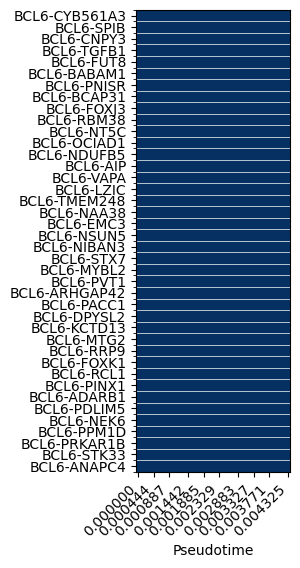

In [83]:
# plot the heatmap of the pairs
fig, ax, dnet = fig_regulation_heatmap(
    network=dictys_dynamic_object,
    start=1,
    stop=3,
    regulations=bcl6_links,
    num=40,
    dist=0.001,
    cmap='RdBu_r' 
)

In [84]:
# get the expression curves of the TFs in the specified links
tf_expression, _ = pseudotime_object.get_smoothed_curves(mode='tf_expression')
regulon_tf_expression = tf_expression.loc[lf_beta_dcurve.index.get_level_values(0).unique()]

In [85]:
force_curves = pseudotime_object.calculate_force_curves(lf_beta_dcurve, regulon_tf_expression)

In [86]:
display(force_curves.shape)

(120, 40)

In [87]:
display(len(bcl6_links))

40

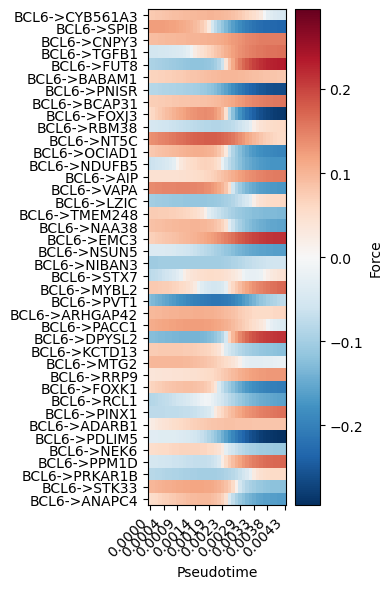

In [88]:
force_df_for_cluster, reg_labels, dtime, fig = plot_force_heatmap_with_clustering(
    force_df=force_curves,
    dtime=dtime,
    regulations=bcl6_links,
    cmap='RdBu_r',
    vmax=None,
    figsize= (4, 6),
    plot_figure=True,
    perform_clustering=False,
    row_scaling=None
)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [89]:
# save the list of bcl6 links, force_curves, dtime as pickles in a folder
root_dir = config.KO_PROGRAM_DIR
os.makedirs(root_dir, exist_ok=True)
# save the list of bcl6 links
with open(os.path.join(root_dir, 'bcl6_links.pkl'), 'wb') as f:
    pickle.dump(bcl6_links, f)
# save the force_curves
with open(os.path.join(root_dir, 'force_curves.pkl'), 'wb') as f:
    pickle.dump(force_curves, f)
# save the dtime
with open(os.path.join(root_dir, 'dtime.pkl'), 'wb') as f:
    pickle.dump(dtime, f)

### comparison of bcl6 activity in prdm1-ko program vs irf4-ko program

## Custom links plots

In [ ]:
custom_lf_pairs = [('PBX3','PAX5'),('RFX3','CEP128'),('CREB3L2','FNDC3A'),('CREB3L2','TXNDC5'),('CREB3L2','TRAM1'),('PAX5','RUNX2')]

In [ ]:
custom_tf_links = [('PRDM1', 'CYB561A3'),('PRDM1', 'SPIB'),('PRDM1','CNPY3'),('PRDM1','TGFB1'),('PRDM1','FUT8'),('PRDM1','BABAM1'),('PRDM1','PNISR'),('PRDM1','BCAP31'),('PRDM1','FOXJ3'),('PRDM1','RBM38'),('PRDM1','NT5C'),('PRDM1','OCIAD1'),('PRDM1','NDUFB5'),('PRDM1','AIP'),('PRDM1','VAPA'),('PRDM1','LZIC'),('PRDM1','TMEM248'),('PRDM1','NAA38'),('PRDM1','EMC3'),('PRDM1','NSUN5'),('PRDM1','NIBAN3'),('PRDM1','STX7'),('PRDM1','MYBL2'),('PRDM1','PVT1'),('PRDM1','ARHGAP42'),('PRDM1','PACC1'),('PRDM1','DPYSL2'),('PRDM1','KCTD13'),('PRDM1','MTG2'),('PRDM1','RRP9'),('PRDM1','FOXK1'),('PRDM1','RCL1'),('PRDM1','PINX1'),('PRDM1','ADARB1'),('PRDM1','PDLIM5'),('PRDM1','NEK6'),('PRDM1','PPM1D'),('PRDM1','PRKAR1B'),('PRDM1','STK33'),('PRDM1','ANAPC4')]

In [ ]:
# plot the heatmap of the cell-cycle pairs
fig, ax, dnet = fig_regulation_heatmap(
    network=dictys_dynamic_object,
    start=1,
    stop=2,
    regulations=custom_tf_links,
    num=50,
    dist=0.0005,
    cmap='RdBu_r' 
)

In [ ]:
print("Original dnet values range:", dnet.min(), "to", dnet.max())
# Convert dnet to DataFrame with row labels
df = pd.DataFrame(dnet, 
                 index=["-".join(x) for x in custom_tf_links])
print("DataFrame values range:", df.values.min(), "to", df.values.max())
# Calculate max absolute value for symmetric color scaling
vmax_val = float(df.abs().values.max())  # Get max from numpy array values

In [ ]:
# Use cluster_heatmap with absolute values for clustering
fig, x, y = cluster_heatmap(df.abs(),  # Use absolute values for clustering
                           dshow=df,    # Show original values in heatmap
                           dtop=0,      # No clustering on time points
                           dright=0.3,  # Cluster the links
                           method='ward',
                           metric='euclidean',
                           cmap='RdYlGn',   # Use the colormap name directly
                           aspect=0.1,
                           xtick=False,
                           vmin=-vmax_val,  # Set minimum value
                           vmax=vmax_val)   # Set maximum value

In [ ]:
# plot expression gradient of RUNX2
fig, ax, cmap = fig_expression_gradient_heatmap(
    network=dictys_dynamic_object,
    start=0,
    stop=2,
    genes_or_regulations=['PAX5', 'RUNX2'],
    num=100,
    dist=0.0005,
    cmap='YlGn' # green is positive yellow is negative
)


#### Get curve characteristics like regulation, expression, etc.

In [ ]:
from focal.temporal import *

In [ ]:
gc_exp_curves_dy, gc_exp_curves_dx = SmoothedCurvesGRN(dictys_dynamic_object,
    trajectory_range=(0,3),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
    mode="expression").get_smoothed_curves()

In [ ]:
gc_reg_curves_dy, gc_reg_curves_dx = SmoothedCurvesGRN(dictys_dynamic_object,
    trajectory_range=(0,3),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
    mode="regulation").get_smoothed_curves()

In [ ]:
# Plot expression trajectories
fig = plt.figure(figsize=(10, 6))
ax = plt.gca()  # Get current axes

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Highlight specific genes
genes_of_interest = ['BACH2','PAX5', 'BATF','NFATC2','IKZF2','RBPJ']
colors = ['green','blue','red','orange','purple','pink']   # Define colors for each gene

for gene, color in zip(genes_of_interest, colors):
    if gene in gc_exp_curves_dy.index:
        line = plt.plot(gc_exp_curves_dx, gc_exp_curves_dy.loc[gene], linewidth=2, color=color)
        # Add label at the end of the line
        plt.text(gc_exp_curves_dx.iloc[-1], gc_exp_curves_dy.loc[gene].iloc[-1], f' {gene}', 
                color=color, 
                verticalalignment='center')

plt.xlabel('Pseudotime')
plt.ylabel('Log (CPM)')
plt.title('GC branch')
#save the figure
plt.savefig(os.path.join(output_folder, 'gc_branch_episodic_tfs_expression.pdf'), dpi=300)
plt.show()

# Animations

In [ ]:
pairs = [('PBX3','PAX5'), ('NRF1','PAX5'),('NRF1','RUNX2'),('PAX5','RUNX2')]

In [ ]:
# plot the heatmap of the lineage pairs
fig, ax_gc, cmap = fig_regulation_heatmap(
    network=dictys_dynamic_object,
    start=0,
    stop=3,
    regulations=pairs,
    num=100,
    dist=0.0005,
    cmap='RdBu'
)

In [ ]:
# Get the raw data from heatmap
heatmap_data_gc = ax_gc.images[0].get_array()

# Get unique TFs and targets from cell_cycle_pairs
tfs_gc = list(set(pair[0] for pair in pairs))
targets_gc = list(set(pair[1] for pair in pairs))

# Function to convert RdBu colors to regulation strength
def rdbu_to_regulation(rgb_values):
    # In RdBu, red indicates positive regulation (R > B)
    # and blue indicates negative regulation (B > R)
    return rgb_values[:, 0] - rgb_values[:, 2]  # R - B gives regulation strength

# Create a dictionary to store actual regulation values
regulation_dict_gc = {}
for row_idx, (tf, target) in enumerate(pairs):
    # Convert RGB values to regulation strength
    regulation_strength = rdbu_to_regulation(heatmap_data_gc[row_idx])
    regulation_dict_gc[(tf, target)] = regulation_strength

# Create 3D array (n_tf x n_target x n_timepoints)
regulation_array_gc = np.zeros((len(tfs_gc), len(targets_gc), heatmap_data_gc.shape[1]))
for tf_idx, tf in enumerate(tfs_gc):
    for target_idx, target in enumerate(targets_gc):
        if (tf, target) in regulation_dict_gc:
            regulation_array_gc[tf_idx, target_idx, :] = regulation_dict_gc[(tf, target)]

print("\nFinal array shape:", regulation_array_gc.shape)
print("TFs:", tfs_gc)
print("Targets:", targets_gc)

#### Animate the subgraph of the mentioned regulations

In [ ]:
# get the weights of the lineage pairs across windows
tf_indices_lineage, tf_gene_indices_lineage, _ = get_tf_indices(dictys_dynamic_object, [pair[0] for pair in pairs])
gene_indices_lineage = get_gene_indices(dictys_dynamic_object, [pair[1] for pair in pairs])


In [ ]:
import networkx as nx
import matplotlib.animation as animation
from matplotlib.patches import ArrowStyle, ConnectionStyle
import matplotlib.pyplot as plt

def create_network_animation(weights, tf_names, target_names, output_path, branch_name):
    """
    Create and save network animation showing weight changes across windows.
    Node positions remain fixed, only edge weights change.
    """
    n_tfs, n_targets, n_windows = weights.shape
    
    # Create initial graph with all possible nodes and edges
    G_init = nx.DiGraph()
    
    # Add TF nodes
    for tf in tf_names:
        G_init.add_node(tf, node_type='TF')
        
    # Add target nodes
    for target in target_names:
        G_init.add_node(target, node_type='target')
    
    # Calculate fixed layout once
    pos = nx.spring_layout(G_init, k=1, iterations=50)
    
    def create_graph(window_idx):
        G = G_init.copy()
        
        # Add edges with weights for this window
        for i, tf in enumerate(tf_names):
            for j, target in enumerate(target_names):
                weight = weights[i, j, window_idx]
                if abs(weight) > 0.1:  # Only show stronger connections
                    G.add_edge(tf, target, weight=weight)
        
        return G
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    def update(frame):
        ax.clear()
        G = create_graph(frame)
        
        # Draw nodes using fixed positions
        tf_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'TF']
        target_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'target']
        
        # Draw nodes
        nx.draw_networkx_nodes(G, pos, nodelist=tf_nodes, node_color='lightblue', 
                             node_size=1000, label='TFs')
        nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, node_color='lightgreen',
                             node_size=1000, label='Targets')
        
        # Draw edges with different styles based on weight
        edges = G.edges(data=True)
        if edges:
            # Separate positive and negative edges with their weights
            pos_edges = [(u, v, abs(d['weight'])) for (u, v, d) in edges if d['weight'] > 0]
            neg_edges = [(u, v, abs(d['weight'])) for (u, v, d) in edges if d['weight'] < 0]
            
            # Function to scale edge widths (min width 1, max width 5)
            def scale_width(weight):
                return 1 + 4 * (weight - 0.1) / (2.0 - 0.1)
            
            # Draw positive edges with arrow
            if pos_edges:
                nx.draw_networkx_edges(G, pos, 
                                     edgelist=[(u,v) for u,v,w in pos_edges], 
                                     edge_color='red',
                                     arrows=True,
                                     arrowsize=20,
                                     width=[scale_width(w) for _,_,w in pos_edges],
                                     arrowstyle='->')
            
            # Draw negative edges with custom repression style
            if neg_edges:
                nx.draw_networkx_edges(G, pos, 
                                     edgelist=[(u,v) for u,v,w in neg_edges],
                                     edge_color='blue',
                                     arrows=True,
                                     arrowsize=20,
                                     width=[scale_width(w) for _,_,w in neg_edges],
                                     arrowstyle='->')
        
        # Add labels with fixed positions
        nx.draw_networkx_labels(G, pos)
        
        # Add title and window info
        plt.title(f'Window {frame + 1}/{n_windows}')
        
        # Add legend with smaller markers
        plt.legend(markerscale=0.5, prop={'size': 8})
        
        return ax

    # Create animation
    anim = animation.FuncAnimation(fig, update, frames=n_windows, 
                                 interval=200, blit=False)
    
    # Save animation
    output_file = os.path.join(output_path, f'network_animation_{branch_name}.mp4')
    anim.save(output_file, writer='ffmpeg', fps=15)
    plt.close()
    
    return output_file

In [ ]:
# First, let's verify our data
print("Regulation array shape:", regulation_array_gc.shape)
print("TFs:", tfs_gc)
print("Targets:", targets_gc)
print("Lineage pairs:", pairs)

# Create animation with the correct TF and target lists
output_file = create_network_animation(
    weights=regulation_array_gc,
    tf_names=tfs_gc,  # Use tfs_pb instead of extracting from lineage_pairs
    target_names=targets_gc,  # Use targets_pb instead of extracting from lineage_pairs
    output_path=config.DICTYS_OUTPUT,
    branch_name='GC'
)

print(f"Animation saved to: {output_file}")

### Branch specific animations

In [ ]:
branches={
	'Plasmablast':(1,2),
	'Germinal-center':(1,3)
}
#Value range for coloring
vrange={
	'Terminal logFC':[-4,4],
	'Transient logFC':[-4,4],
	'Switching time':[0.0015,0.0045],
}

#### Update dictys object with cell type lables

In [ ]:
cell_labels_file = config.CELL_LABELS
#read the columns barcodes and cluster
cell_labels_df = pd.read_csv(cell_labels_file)
cell_labels = cell_labels_df['Cluster']
# Convert pandas Series to plain list, removing the index
cell_type_list = cell_labels.values.tolist() if isinstance(cell_labels, pd.Series) else list(cell_labels)
dictys_dynamic_object.prop['c']['color'] = cell_type_list
print(f"Number of cells with color labels: {len(dictys_dynamic_object.prop['c']['color'])}")
print(f"First few labels: {dictys_dynamic_object.prop['c']['color'][:5]}")

In [ ]:
from IPython.display import FileLink
from dictys.plot import layout,panel
# Number of frames (interpolated time points/equispaced time points), use 100 or higher for finer resolution
nframe=20
# Animation FPS for saving. Determines speed of play
fps=0.10*nframe
# DPI for animation
dpi=100


In [ ]:
branchname='Plasmablast'
# Select TFs for each row's dynamic subnetwork graph
tfs_subnet=[
	['PRDM1']
]
# Select TFs for each row's other plots
tfs_ann=[
	['IRF4','PRDM1','BATF', 'SPIB', 'BACH2']
]
# Select genes to annotate as targets in all rows
target_ann=['RUNX2','MZB1','PRDM1','AFF3', 'IRF4']


In [ ]:
branch=branches[branchname]
# initialize layout with dist, n_points, dpi
layout1=layout.notch(dist=0.0005,nframe=nframe,dpi=dpi)
pts,fig,panels,animate_ka=layout1.draw(
	dictys_dynamic_object,branch,
	# Set genes to annotate
	bcde_tfs=tfs_ann,e_targets=target_ann,f_tfs=tfs_subnet,
	# Custom legend location for long cell type name
	a_ka={'scatterka':{'legend_loc':(0.6,1)}},
	# Custom configurations for color range
	e_ka={'lim':[-0.02,0.02]},
)
ca=panel.animate_generic(pts,fig,panels)
anim=ca.animate(**animate_ka)


In [ ]:
w=matplotlib.animation.writers['ffmpeg_file'](fps=fps,codec='h264')
w.frame_format='jpeg'
fo=f"{config.DICTYS_OUTPUT}/20frames-{branchname}.mp4"
anim.save(fo,writer=w,dpi='figure')
display(FileLink(fo))


### Print window labels 

In [ ]:
# get the proportion of cell types in each window
cell_labels_file = config.CELL_LABELS
#read the columns barcodes and cluster
cell_labels_df = pd.read_csv(cell_labels_file, index_col=0)
cell_labels = cell_labels_df['Cluster']

In [ ]:
# get the top 3 states from window 1,97,96 : 0,98,: 146,2: 193, 3
top_3_states = get_top_k_fraction_labels(dictys_dynamic_object, 135, cell_labels, k=3)
sorted_states = sorted(top_3_states, key=lambda x: x[1][0], reverse=True)
display(sorted_states)

In [ ]:
# Create custom legend handles and labels
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

leiden_color_dict = {
    'ActB-1': 'lightskyblue',     # light blue cluster at bottom
    'ActB-2': 'dodgerblue',       # darker blue cluster
    'ActB-4': 'mediumorchid',     # purple cluster
    'GC-1': 'limegreen',          # bright green cluster
    'ActB-3': 'darkblue',         # dark blue cluster
    'Naive': 'darkgray',          # gray cluster on left
    'GC-2': 'green',              # darker green cluster
    'PB-2': 'firebrick',          # red cluster
    'earlyPB': 'lightcoral',      # pink/coral cluster
    'earlyActB': 'teal'           # teal cluster
}
# Create custom legend handles and labels
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=leiden_color_dict[state[0]], 
           markersize=8, label=f'$\\mathbf{{{state[1][0]*100:.1f}}}$% {state[0]} state')
    for state in sorted_states
]

# Create a figure and axis
fig, ax = plt.subplots(figsize=(3, 2))  # Adjusted figure size for vertical layout
ax.set_visible(False)  # Hide the axis

# Add the legend to the figure vertically
fig.legend(handles=legend_elements, 
          loc='center', 
          ncol=1,  # Changed to 1 column for vertical layout
          frameon=False)
plt.savefig(f"{config.DICTYS_FIGURES}/legend_w135.pdf", 
            bbox_inches='tight',  # Ensures the legend isn't cut off
            dpi=300,             # High resolution
            format='pdf')
